In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

In [4]:
from zipfile import ZipFile

with ZipFile("/content/drive/MyDrive/archive (3).zip", "r") as zip_ref:
    zip_ref.extractall("/content/drive/MyDrive/")

In [7]:
train_dir = "/content/drive/MyDrive/PlantVillage/train"
val_dir = "/content/drive/MyDrive/PlantVillage/val"

In [8]:
import os

print("Train classes:", len(os.listdir("/content/drive/MyDrive/PlantVillage/train")))
print("Validation classes:", len(os.listdir("/content/drive/MyDrive/PlantVillage/val")))

Train classes: 38
Validation classes: 38


Importing the dependencies

In [9]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [13]:
import os

train_dir = "/content/drive/MyDrive/PlantVillage/train"
val_dir = "/content/drive/MyDrive/PlantVillage/val"

print(f"Train classes: {len(os.listdir(train_dir))}")
print(f"Validation classes: {len(os.listdir(val_dir))}")

print("\nFirst 5 training classes:")
print(sorted(os.listdir(train_dir))[:5])

Train classes: 38
Validation classes: 38

First 5 training classes:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


Number of classes=38

Data Preprocessing

In [14]:
# Dataset Path
train_dir = "/content/drive/MyDrive/PlantVillage/train"
val_dir = "/content/drive/MyDrive/PlantVillage/val"

(256, 256, 3)


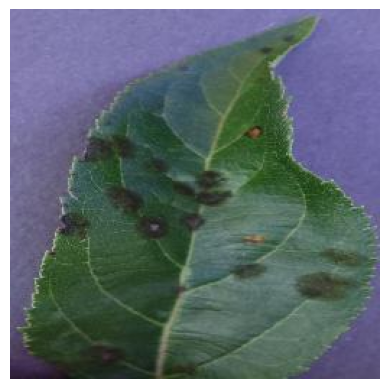

In [16]:
image_path = '/content/drive/MyDrive/PlantVillage/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG'
# Read the image
img = mpimg.imread(image_path)

print(img.shape)
# Display the image
plt.imshow(img)
plt.axis('off')  # Turn off axis numbers
plt.show()

In [17]:
# Image Parameters
img_size = 224
batch_size = 32

In [18]:
classes = sorted(os.listdir(train_dir))
print("Number of classes:", len(classes))
print(classes)

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

Train Test Split

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [20]:
# Train Generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

Found 43444 images belonging to 38 classes.


In [21]:
# Validation Generator
validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 10861 images belonging to 38 classes.


Convolutional Neural Network

In [22]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load pre-trained MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

# Freeze the pre-trained layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)  # Reduce overfitting
predictions = Dense(
    train_generator.num_classes,
    activation="softmax"
)(x)

# Build the final model
model = Model(
    inputs=base_model.input,
    outputs=predictions
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [24]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_plant_disease_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

Model training

In [26]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.4448 - loss: 2.2158
Epoch 1: val_accuracy improved from None to 0.83224, saving model to best_plant_disease_model.keras

Epoch 1: finished saving model to best_plant_disease_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 914s 656ms/step - accuracy: 0.6012 - loss: 1.5486 - val_accuracy: 0.8322 - val_loss: 0.6790
Epoch 2/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.7791 - loss: 0.7804
Epoch 2: val_accuracy improved from 0.83224 to 0.88666, saving model to best_plant_disease_model.keras

Epoch 2: finished saving model to best_plant_disease_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 803s 591ms/step - accuracy: 0.7970 - loss: 0.7104 - val_accuracy: 0.8867 - val_loss: 0.4298
Epoch 3/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8374 - loss: 0.5538
Epoch 3: val_accuracy improved from 0.88666 to 0.90774, saving model to best_plant_disease_model.keras

Epoch 3: finished saving model to best_plant_

KeyboardInterrupt: 

In [29]:
import shutil

shutil.copy(
    "best_plant_disease_model.keras",
    "/content/drive/MyDrive/best_plant_disease_model.keras"
)

print("Copied successfully!")

Copied successfully!


In [30]:
import os
print(os.path.exists("/content/drive/MyDrive/best_plant_disease_model.keras"))

True


In [31]:
import json

with open("class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)

import shutil
shutil.copy(
    "class_indices.json",
    "/content/drive/MyDrive/class_indices.json"
)

print("class_indices.json saved successfully!")

class_indices.json saved successfully!


In [37]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/best_plant_disease_model.keras")

train_loss, train_acc = model.evaluate(train_generator)
val_loss, val_acc = model.evaluate(validation_generator)

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 730s 533ms/step - accuracy: 0.9437 - loss: 0.1810
340/340 ━━━━━━━━━━━━━━━━━━━━ 51s 150ms/step - accuracy: 0.9449 - loss: 0.1838
Training Accuracy: 94.37%
Validation Accuracy: 94.49%


In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

validation_generator.reset()

y_pred = model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = validation_generator.classes

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=list(validation_generator.class_indices.keys())
))

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

340/340 ━━━━━━━━━━━━━━━━━━━━ 65s 168ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.91      0.93       126
                                 Apple___Black_rot       1.00      0.97      0.98       125
                          Apple___Cedar_apple_rust       0.98      0.98      0.98        55
                                   Apple___healthy       0.95      0.97      0.96       329
                               Blueberry___healthy       0.98      0.96      0.97       300
          Cherry_(including_sour)___Powdery_mildew       0.99      0.98      0.98       210
                 Cherry_(including_sour)___healthy       0.99      0.98      0.99       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.81      0.71      0.76       103
                       Corn_(maize)___Common_rust_       0.98      0.99      0.98       239
               Corn_(maize)___North

In [36]:
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

340/340 ━━━━━━━━━━━━━━━━━━━━ 58s 152ms/step - accuracy: 0.9449 - loss: 0.1838
Validation Accuracy: 94.49%


In [38]:
import json

with open("class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)

In [39]:
import shutil

shutil.copy(
    "class_indices.json",
    "/content/drive/MyDrive/class_indices.json"
)

'/content/drive/MyDrive/class_indices.json'

Building a Predictive System

In [40]:

def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(target_size)
    img_array = np.array(img).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    img = load_and_preprocess_image(image_path)

    predictions = model.predict(img, verbose=0)

    predicted_index = np.argmax(predictions)
    confidence = float(np.max(predictions))

    predicted_class = class_indices[predicted_index]

    return predicted_class, confidence

In [47]:
import json

with open("class_indices.json", "r") as f:
    class_indices = json.load(f)